# B-3403C — AutoML

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from clearml import Task
import os

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from transpetro_modelos.config import EQUIPMENT_CONFIGS
from transpetro_modelos.data.loading import load_equipment_data
from transpetro_modelos.data.preprocessing import run_preprocessing

In [2]:
# ==============================
# Configuracao
# ==============================
TASK_ID = '4e70c05f673e496797e1b26c276bcbad'  # obrigatorio
EQUIPMENT_ID = 'B-3403C_interpolated'
USE_FULL_SCORES = True

# Eventos
EVENT_DATE_F1 = '2023-09-12'
EVENT_LABEL_F1 = 'Inicio restricao (12/Set/2023)'
EVENT_TS_F1 = pd.Timestamp(EVENT_DATE_F1)
EVENT_DATE_F2 = '2023-09-13'

PREFAILURE_DAYS=7 
NORMAL_END_DAYS=20

KEY_SENSORS=['Corrente', 'Press Desc', 'Press Suc', 'Pressão Lubrificação',
       'Temperatura Enrolamento', 'Temperatura Lubrificação Tanque',
       'Temperatura Mancal Bomba LA', 'Temperatura Mancal Bomba LNA Axial',
       'Temperatura Mancal Bomba LNA Radial', 'Temperatura Mancal Motor LA',
       'Temperatura Mancal Motor LNA', 'Vibração']

SAVE_PLOTS=False; OUTPUT_DPI=200; OUTPUT_DIR=str(PROJECT_ROOT/'notebooks'/'b3403c'/'plots_full')

# Sensibilidade
AUTO_USE_CALIBRATED_SENSITIVITY = True
SENSITIVITY_PRESET = 'conservative'  # 'conservative' | 'balanced' | 'sensitive' | 'custom'
CALIB_START = '2023-04-01'
CALIB_END = '2023-06-30'
CALIB_PERCENTILES = [95, 97, 98, 99, 99.5, 99.7, 99.9]
CALIB_PERSISTENCE_GRID = [(1, 1), (2, 3), (3, 5), (4, 6)]
TARGET_ALERTS_PER_DAY = 2.0

# Visualizacao
PLOT_MODE = 'separated'  # 'separated' | 'consolidated'
ANOMALY_HIGHLIGHT_STYLE = 'lollipop'  # 'lollipop' | 'big_points'
SAVE_PLOTS = False
OUTPUT_DPI = 180
FIGSIZE_WIDTH = 12
PANEL_HEIGHT = 2.5

In [3]:
def load_scores(task_id):
    task = Task.get_task(task_id=task_id)
    s = task.artifacts['best_scores'].get()
    s.index = pd.to_datetime(s.index); s = s.sort_index()
    s['is_anomaly'] = s['is_anomaly'].astype(bool)
    res = task.artifacts['automl_ranking'].get() if 'automl_ranking' in task.artifacts else None
    bt = task.artifacts['best_trial'].get() if 'best_trial' in task.artifacts else None
    return s[['reconstruction_error','is_anomaly']], res, bt, task

def persistence_filter(flags, k, n):
    if k==1 and n==1: return flags.astype(bool)
    return (flags.astype(int).rolling(window=n, min_periods=n).sum() >= k).fillna(False).astype(bool)

def load_plot_base(equipment_id: str):
    config = EQUIPMENT_CONFIGS[equipment_id]
    df_raw = load_equipment_data(equipment_id, from_clearml=False)

    # Pre-split para alinhar timestamps da serie de sensores ao score
    pre_steps = config.pre_split_steps

    if pre_steps:
        df_base, _, _ = run_preprocessing(df_raw, pre_steps, fitted_scaler=None)
    else:
        df_base = df_raw

    df_base = df_base.sort_index()
    df_base.index = pd.to_datetime(df_base.index)
    return df_base, config

def model_info_str(bt):
    return (f"Modelo AutoML: {str(bt.get('model')).upper()} / {bt.get('preset')} / p{bt.get('threshold_percentile')} / "
            f"debounce {bt.get('debounce_consecutive')}  ·  pré-falha {bt.get('prefailure_alert_rate',0):.0%} @ FP {bt.get('normal_alert_rate',0):.1%}")

def _slug(t): return ''.join(c if c.isalnum() else '_' for c in str(t)).strip('_').lower()

def plot_separated(df_window, scores_window, sensors, threshold, k, n, event_ts, event_label,
                   prefailure_days, title_prefix, tag, threshold_label='Limiar', model_info='',
                   shade=True, save=False, outdir=None, dpi=200):
    plt.style.use('seaborn-v0_8-whitegrid')
    flags = persistence_filter(scores_window['reconstruction_error'] > threshold, k=k, n=n)
    anom_idx = scores_window.index[flags]
    if save and outdir:
        from pathlib import Path as _P; _P(outdir).mkdir(parents=True, exist_ok=True)
    saved=[]
    panels = list(sensors) + ['__score__']
    for col in panels:
        fig, ax = plt.subplots(figsize=(14,3.2))
        if col == '__score__':
            y=scores_window['reconstruction_error']
            ax.plot(y.index,y,color='purple',lw=0.9,alpha=0.6,label='Score de Anomalia')
            ax.axhline(threshold,color='red',ls='--',lw=1.2,label=threshold_label)
            if len(anom_idx): ax.scatter(anom_idx,y.reindex(anom_idx),s=28,color='red',zorder=4,label='Alerta')
            ax.set_ylabel('Score'); ttl='Score de Anomalia'
        else:
            if col not in df_window.columns: plt.close(fig); continue
            ax.plot(df_window.index, df_window[col], color='steelblue', lw=1.0, alpha=0.85, label=col)
            av = df_window[col].reindex(anom_idx).dropna()
            if not av.empty: ax.scatter(av.index, av.values, s=28, color='red', zorder=4, label='Anomalia')
            ax.set_ylabel(col, fontsize=9); ttl=col
        if shade: ax.axvspan(event_ts-pd.Timedelta(days=prefailure_days), event_ts, color='orange', alpha=0.08)
        ax.axvline(event_ts, color='orange', ls='--', lw=1.4, label=event_label)
        ax.set_xlabel('Tempo'); ax.legend(loc='upper left', fontsize=8)
        ax.set_title(f'{title_prefix} | {ttl}', fontsize=12, fontweight='bold')
        if model_info: ax.text(0.5,1.10, model_info, transform=ax.transAxes, ha='center', va='bottom', fontsize=8, color='dimgray')
        fig.tight_layout()
        if save and outdir: p=f'{outdir}/{tag}_{_slug(ttl)}.png'; fig.savefig(p,dpi=dpi,bbox_inches='tight'); saved.append(p)
        plt.show()
    return saved

In [4]:
scores, automl_results, best_trial, task = load_scores(TASK_ID)
df_base, cfg = load_plot_base(EQUIPMENT_ID)
MODEL_INFO = model_info_str(best_trial)
print('Task:', task.name, '| trials:', len(automl_results))
print(MODEL_INFO)

KeyboardInterrupt: 

In [5]:
cols=[x for x in ['model','preset','threshold_percentile','debounce_consecutive','prefailure_alert_rate','normal_alert_rate','composite_score'] if x in automl_results.columns]
fmt={'prefailure_alert_rate':'{:.2%}','normal_alert_rate':'{:.2%}','composite_score':'{:.4f}','threshold_percentile':'{:.1f}'}
display(automl_results[cols].head(10).style.format(fmt).background_gradient(subset=['prefailure_alert_rate'],cmap='Greens').background_gradient(subset=['normal_alert_rate'],cmap='Reds_r'))

,model,preset,threshold_percentile,debounce_consecutive,prefailure_alert_rate,normal_alert_rate,composite_score
0,dense,moving_average_interpolated,95.0,4,66.78%,2.04%,0.8890
1,dense,baseline_interpolated,95.0,1,66.52%,3.58%,0.8875
2,dense,moving_average_interpolated,95.0,1,66.35%,4.10%,0.8867
3,dense,moving_average_interpolated,95.0,1,65.60%,4.56%,0.8839
4,dense,moving_average_interpolated,95.0,4,65.35%,3.77%,0.8835
5,dense,moving_average_interpolated,95.0,1,65.26%,4.35%,0.8829
6,dense,moving_average_interpolated,95.0,6,65.20%,2.32%,0.8836
7,dense,baseline_interpolated,97.5,1,65.06%,1.34%,0.8834
8,dense,moving_average_interpolated,95.0,4,65.06%,1.97%,0.8833
9,dense,baseline_interpolated,95.0,1,64.93%,4.29%,0.8819


In [6]:
def calculate_metrics(scores, threshold, k, n, event_ts, prefailure_days, normal_end_days):
    """
    Calcula métricas para uma combinação de threshold + debounce
    """
    # Extrair reconstruction error
    _e = scores['reconstruction_error']
    
    # Definir períodos
    _ne = event_ts - pd.Timedelta(days=normal_end_days)
    _ps = event_ts - pd.Timedelta(days=prefailure_days)
    
    _mn = scores.index < _ne                                           # Normal
    _mp = (scores.index >= _ps) & (scores.index < event_ts)           # Pré-falha
    _mpost = scores.index >= event_ts                                 # Pós-falha
    _early = (scores.index >= event_ts - pd.Timedelta(days=14)) & (scores.index < _ps)  # Early
    
    # Aplicar threshold + debounce
    flags = persistence_filter(_e > threshold, k, n)
    
    # Calcular métricas
    prefailure_rate = flags[_mp].mean() if _mp.sum() > 0 else 0
    normal_rate = flags[_mn].mean() if _mn.sum() > 0 else 0
    early_count = int(flags[_early].sum())
    post_count = int(flags[_mpost].sum())
    prefailure_count = int(flags[_mp].sum())
    normal_count = int(flags[_mn].sum())
    
    return {
        'threshold': threshold,
        'k': k,
        'n': n,
        'prefailure_rate': prefailure_rate,
        'prefailure_count': prefailure_count,
        'normal_rate': normal_rate,
        'normal_count': normal_count,
        'early_count': early_count,
        'post_count': post_count,
        'flags': flags
    }

_e = scores['reconstruction_error']
_ne = EVENT_TS_F1 - pd.Timedelta(days=NORMAL_END_DAYS)
_ps = EVENT_TS_F1 - pd.Timedelta(days=PREFAILURE_DAYS)
_mn = scores.index < _ne

# Testar diferentes percentis
print("🔍 Explorando diferentes percentis de threshold:\n")

percentiles = [95.0, 97.5, 99.0, 99.5, 99.7, 99.9]
results_percentile = []

for p in percentiles:
    thr = float(np.percentile(_e[_mn].values, p))
    m = calculate_metrics(scores, thr, 1, 1, EVENT_TS_F1, PREFAILURE_DAYS, NORMAL_END_DAYS)
    results_percentile.append(m)
    print(f"  p{p:5.1f}  →  Pré-falha: {m['prefailure_rate']:6.1%} | Normal: {m['normal_rate']:6.2%} | Threshold: {thr:.6f}")

df_percentiles = pd.DataFrame(results_percentile)
print(f"\n✓ {len(df_percentiles)} combinações testadas")

# Grid Search: Priorizar Redução de FP
print("\n🔍 Grid Search: Priorizar Redução de FP\n")

percentiles = [95.0, 97.5, 99.0, 99.5, 99.7, 99.9]
debounces = [(1,1), (2,3), (3,5), (5,7), (10,12), (12,15), (15,20)]

results = []

for p in percentiles:
    thr = float(np.percentile(_e[_mn].values, p))
    for k, n in debounces:
        m = calculate_metrics(scores, thr, k, n, EVENT_TS_F1, PREFAILURE_DAYS, NORMAL_END_DAYS)
        m['percentile'] = p
        
        score = -m['normal_rate'] * 10 + m['prefailure_rate'] * 1
        m['score'] = score
        m['priority'] = 'FP'
        
        results.append(m)

df_results = pd.DataFrame(results)
df_sorted = df_results.sort_values('score', ascending=False)

print(f"✓ {len(df_results)} combinações testadas\n")
print(f"Score = -FP×10 + Pré-falha×1")
print(f"(Prioriza FP baixo, mantém pré-falha)\n")

🔍 Explorando diferentes percentis de threshold:

  p 95.0  →  Pré-falha: 100.0% | Normal:  5.00% | Threshold: 0.004161
  p 97.5  →  Pré-falha: 100.0% | Normal:  2.50% | Threshold: 0.004972
  p 99.0  →  Pré-falha: 100.0% | Normal:  1.00% | Threshold: 0.006574
  p 99.5  →  Pré-falha: 100.0% | Normal:  0.50% | Threshold: 0.008438
  p 99.7  →  Pré-falha:  99.7% | Normal:  0.30% | Threshold: 0.009581
  p 99.9  →  Pré-falha:  98.8% | Normal:  0.10% | Threshold: 0.012487

✓ 6 combinações testadas

🔍 Grid Search: Priorizar Redução de FP

✓ 42 combinações testadas

Score = -FP×10 + Pré-falha×1
(Prioriza FP baixo, mantém pré-falha)



In [7]:
print("="*80)
print(" TOP 10: PRIORIZAR REDUÇÃO DE FP")
print("="*80 + "\n")

top_10 = df_sorted.head(10)

best_row = df_sorted.iloc[0]
CURRENT_PERCENTILE = best_row['percentile']
CURRENT_K = int(best_row['k'])
CURRENT_N = int(best_row['n'])

print(f"Melhor encontrada: p{CURRENT_PERCENTILE} + k={CURRENT_K}/n={CURRENT_N}\n")

for i, (idx, row) in enumerate(top_10.iterrows(), 1):
    marker = " ← MELHOR" if (row['percentile'] == CURRENT_PERCENTILE and 
                              row['k'] == CURRENT_K and row['n'] == CURRENT_N) else ""
    print(f"{i:2d}. p{row['percentile']:5.1f} | k={row['k']:2.0f}/n={row['n']:2.0f}  →  "
          f"FP: {row['normal_rate']:5.2%} | Pré: {row['prefailure_rate']:6.1%} | "
          f"Early: {row['early_count']:3.0f} | Score: {row['score']:7.3f}{marker}")

print("\n" + "="*80)
print("\nScore = -FP×10 + Pré-falha×1")
print("Quanto MAIOR o score, MELHOR (menos FP)\n")

 TOP 10: PRIORIZAR REDUÇÃO DE FP

Melhor encontrada: p99.7 + k=15/n=20

 1. p 99.7 | k=15/n=20  →  FP: 0.04% | Pré: 100.0% | Early: 6325 | Score:   0.996 ← MELHOR
 2. p 99.7 | k=12/n=15  →  FP: 0.06% | Pré: 100.0% | Early: 6327 | Score:   0.994
 3. p 99.7 | k=10/n=12  →  FP: 0.07% | Pré: 100.0% | Early: 6329 | Score:   0.993
 4. p 99.5 | k=15/n=20  →  FP: 0.13% | Pré: 100.0% | Early: 6328 | Score:   0.987
 5. p 99.9 | k= 5/n= 7  →  FP: 0.02% | Pré:  98.7% | Early: 6323 | Score:   0.985
 6. p 99.9 | k= 3/n= 5  →  FP: 0.06% | Pré:  99.0% | Early: 6328 | Score:   0.984
 7. p 99.7 | k= 5/n= 7  →  FP: 0.16% | Pré: 100.0% | Early: 6339 | Score:   0.984
 8. p 99.5 | k=12/n=15  →  FP: 0.16% | Pré: 100.0% | Early: 6330 | Score:   0.984
 9. p 99.9 | k= 2/n= 3  →  FP: 0.07% | Pré:  99.0% | Early: 6328 | Score:   0.982
10. p 99.5 | k=10/n=12  →  FP: 0.18% | Pré: 100.0% | Early: 6332 | Score:   0.982


Score = -FP×10 + Pré-falha×1
Quanto MAIOR o score, MELHOR (menos FP)



In [8]:
_e=scores['reconstruction_error']; _ne=EVENT_TS_F1-pd.Timedelta(days=NORMAL_END_DAYS); _ps=EVENT_TS_F1-pd.Timedelta(days=PREFAILURE_DAYS)
_mn=scores.index<_ne; _mp=(scores.index>=_ps)&(scores.index<EVENT_TS_F1); _mpost=scores.index>=EVENT_TS_F1
_early=(scores.index>=EVENT_TS_F1-pd.Timedelta(days=14))&(scores.index<_ps)
TUNE_PERCENTILE=99.9; TUNE_K,TUNE_N=15,20

selected_threshold=float(np.percentile(_e[_mn].values,TUNE_PERCENTILE)); selected_k,selected_n=TUNE_K,TUNE_N
threshold_label=f'Limiar p{TUNE_PERCENTILE} + debounce {TUNE_K}/{TUNE_N}'
flags=persistence_filter(_e>selected_threshold,selected_k,selected_n)

print(threshold_label); print('-'*54)
print(f'  PRÉ-FALHA (7d):        {flags[_mp].mean():.1%}  ({int(flags[_mp].sum())})')
print(f'  FP precoce (14-7d):    {int(flags[_early].sum())} alertas')
print(f'  NORMAL (<-20d):        {flags[_mn].mean():.2%}  ({int(flags[_mn].sum())})')
print(f'  pós-falha (evento+reinicio): {int(flags[_mpost].sum())}')

Limiar p99.9 + debounce 15/20
------------------------------------------------------
  PRÉ-FALHA (7d):        97.7%  (761)
  FP precoce (14-7d):    6309 alertas
  NORMAL (<-20d):        0.00%  (0)
  pós-falha (evento+reinicio): 1140


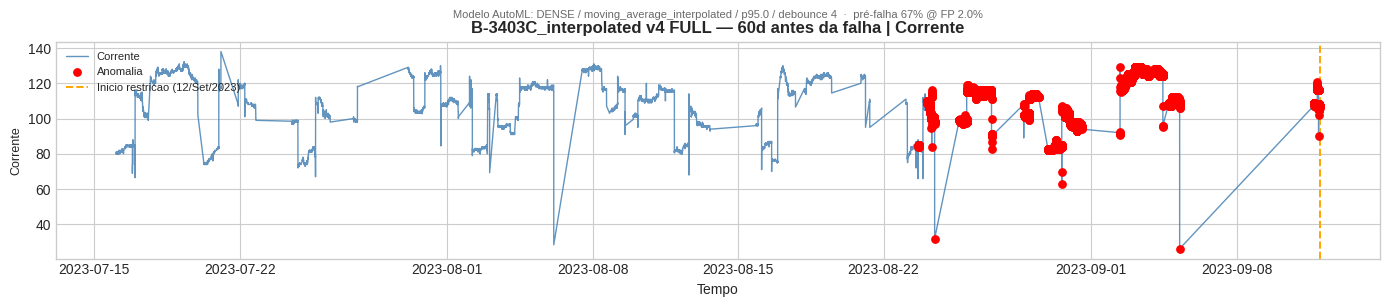

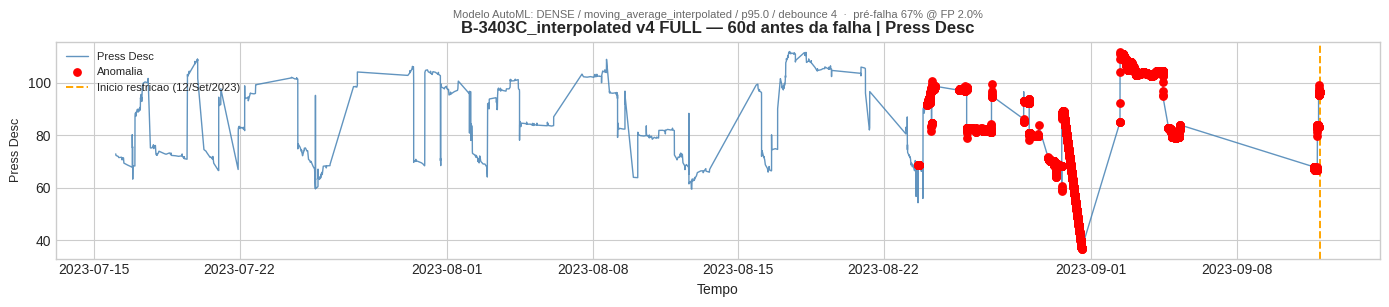

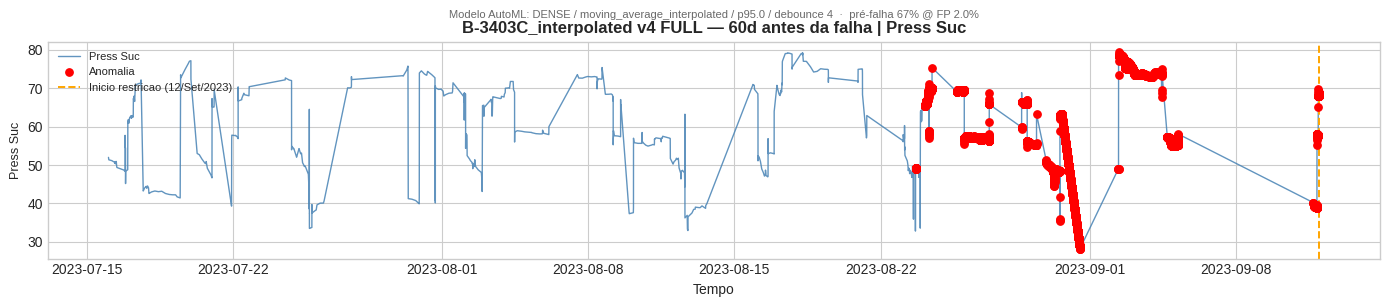

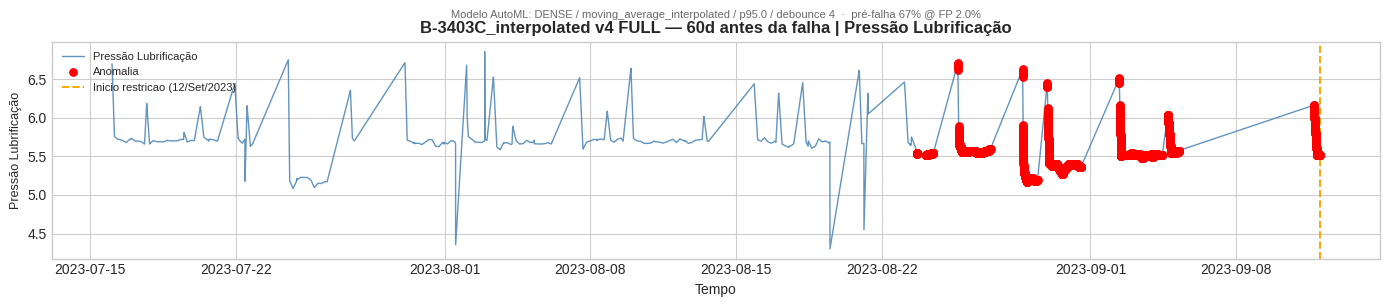

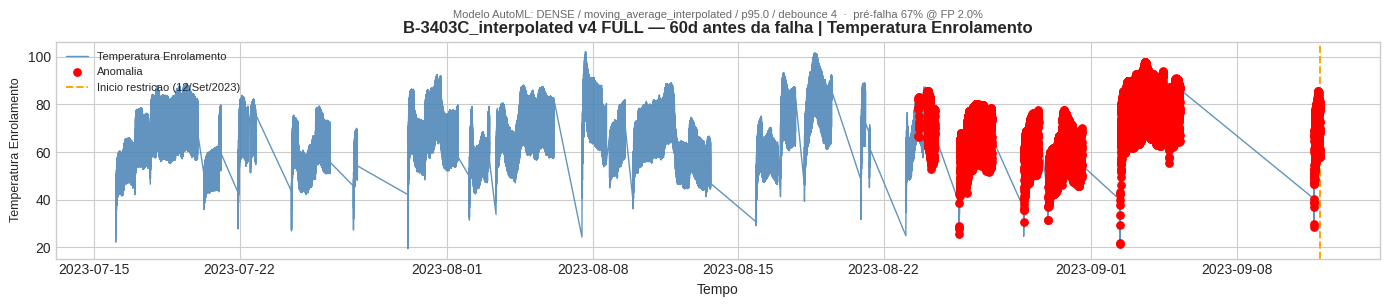

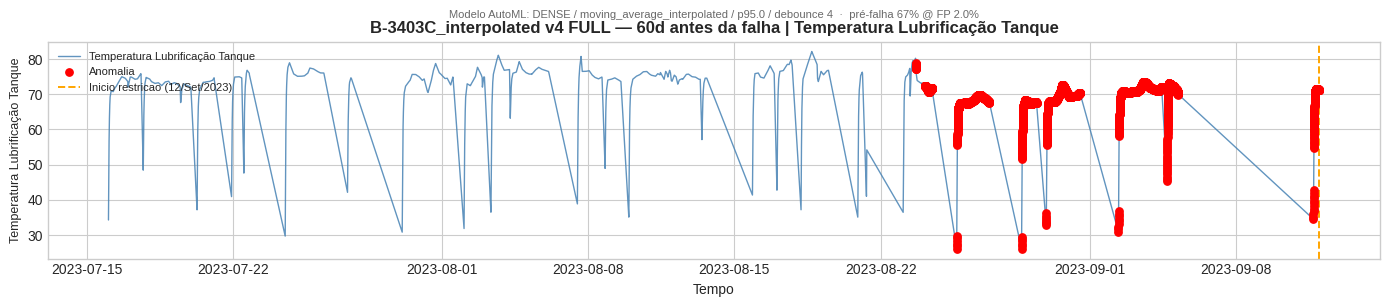

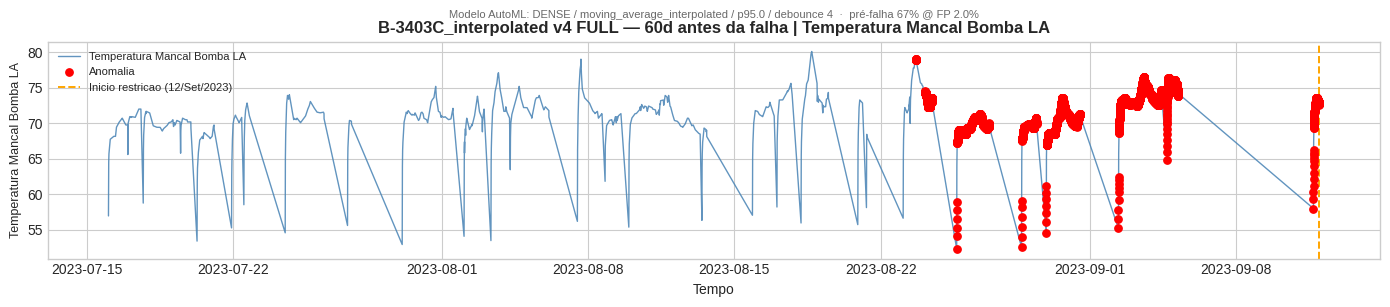

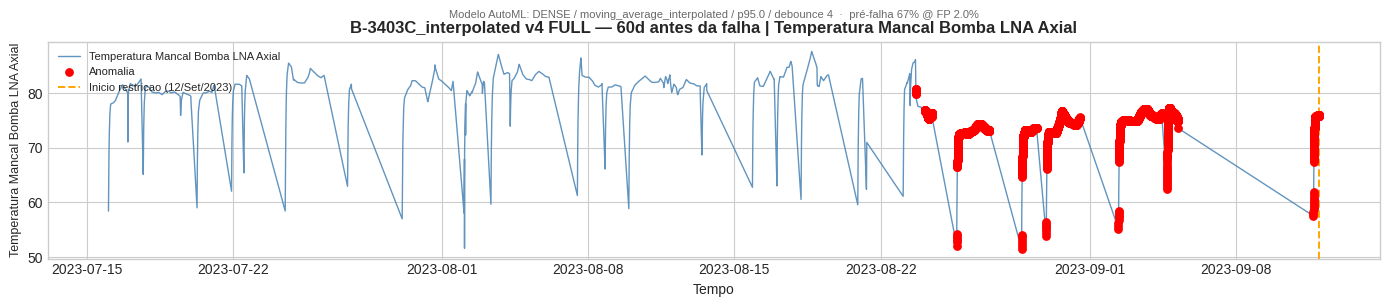

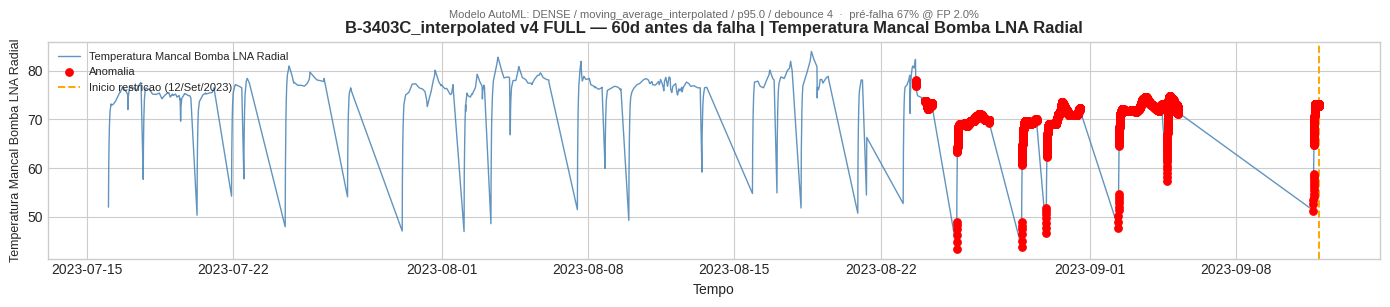

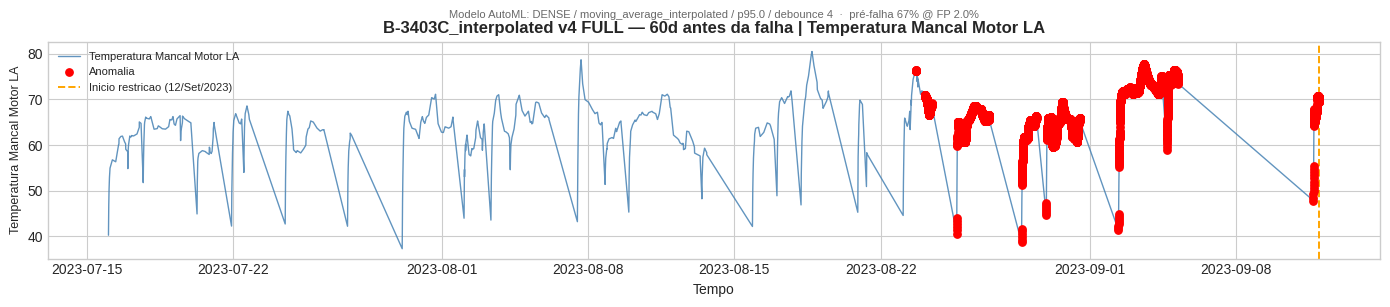

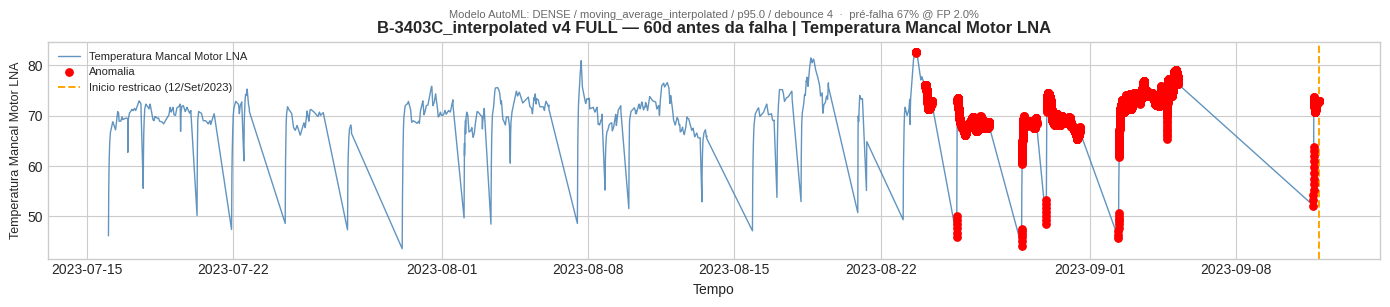

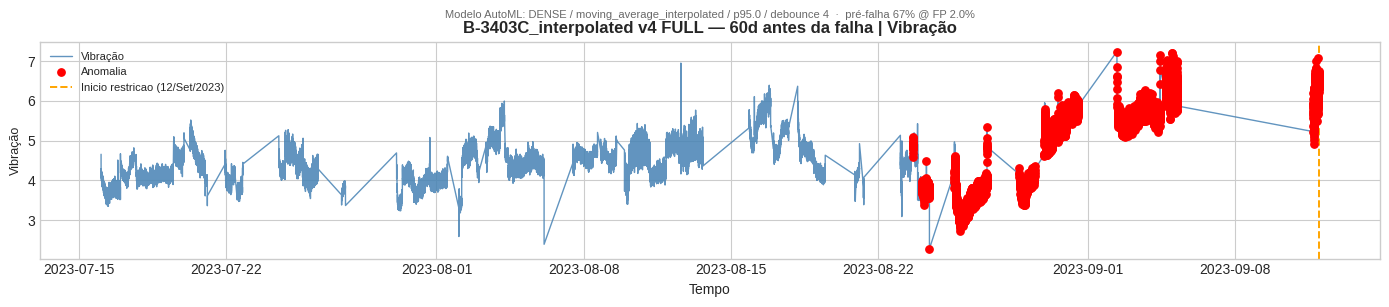

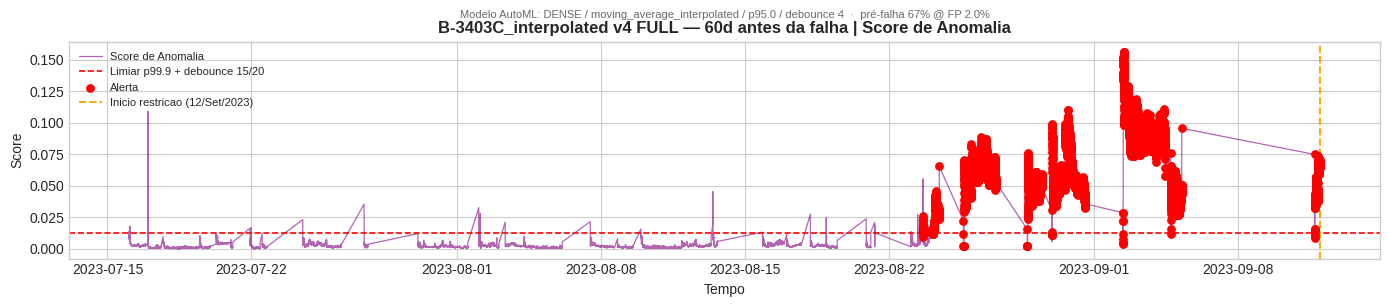

In [9]:
days = 60
z=EVENT_TS_F1-pd.Timedelta(days=days); dfw=df_base.loc[z:EVENT_TS_F1]; sw=scores.loc[z:EVENT_TS_F1]
common=dfw.index.intersection(sw.index); dfw,sw=dfw.loc[common],sw.loc[common]

sensors=[s for s in KEY_SENSORS if s in dfw.columns]

saved=plot_separated(dfw,sw,sensors,selected_threshold,selected_k,selected_n,EVENT_TS_F1,EVENT_LABEL_F1,PREFAILURE_DAYS,
   title_prefix=f'{EQUIPMENT_ID} v4 FULL — {days}d antes da falha',tag='full_zoom14d',threshold_label=threshold_label,
   model_info=MODEL_INFO,shade=False,save=SAVE_PLOTS,outdir=OUTPUT_DIR,dpi=OUTPUT_DPI)

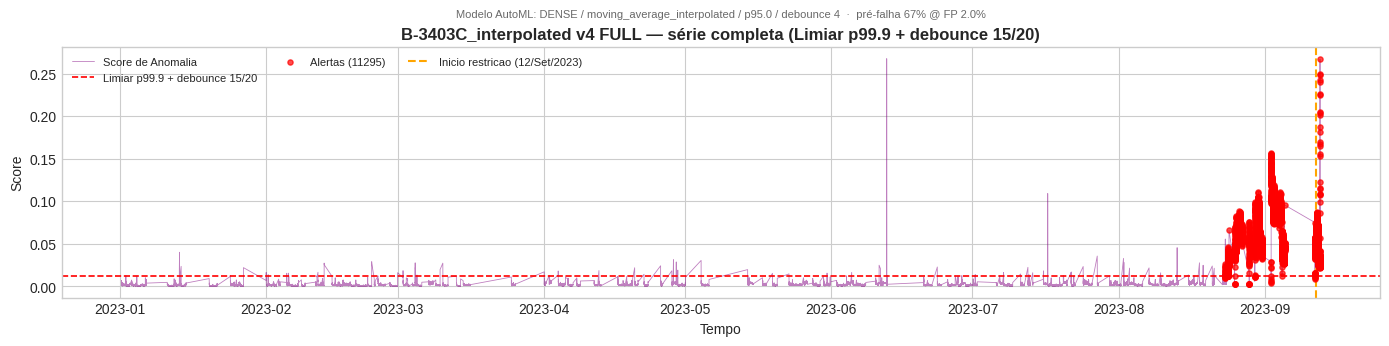

Alertas na série inteira: 11295 | no começo (normal, <-20d): 0
depois do evento F2 (pós-falha): 0


In [10]:
plt.style.use('seaborn-v0_8-whitegrid'); fig,ax=plt.subplots(figsize=(14,3.6)); y=scores['reconstruction_error']

fl_all=persistence_filter(y>selected_threshold, selected_k, selected_n)
ax.plot(scores.index,y,color='purple',lw=0.6,alpha=0.5,label='Score de Anomalia')
ax.axhline(selected_threshold,color='red',ls='--',lw=1.2,label=threshold_label)

idx=scores.index[fl_all]; ax.scatter(idx,y[idx],s=14,color='red',alpha=0.7,zorder=4,label=f'Alertas ({len(idx)})')
ax.axvline(EVENT_TS_F1,color='orange',ls='--',lw=1.5,label=EVENT_LABEL_F1)
ax.set_ylabel('Score'); ax.set_xlabel('Tempo'); ax.legend(loc='upper left',fontsize=8,ncol=3)
ax.set_title(f'{EQUIPMENT_ID} v4 FULL — série completa ({threshold_label})',fontweight='bold')
ax.text(0.5,1.12,MODEL_INFO,transform=ax.transAxes,ha='center',fontsize=8,color='dimgray'); fig.tight_layout()

if SAVE_PLOTS: os.makedirs(OUTPUT_DIR,exist_ok=True); fig.savefig(f'{OUTPUT_DIR}/full_serie_completa.png',dpi=OUTPUT_DPI,bbox_inches='tight')
plt.show(); print(f'Alertas na série inteira: {int(fl_all.sum())} | no começo (normal, <-20d): {int(fl_all[scores.index<EVENT_TS_F1-pd.Timedelta(days=NORMAL_END_DAYS)].sum())}')
alertas_pos_falha = int(fl_all[scores.index >= EVENT_DATE_F2].sum())
print(f'depois do evento F2 (pós-falha): {alertas_pos_falha}')